# Customer Churn Predictor

### Import libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Load Dataset

In [36]:
df = pd.read_csv("../data/raw/Bank-Customer-Churn-Prediction.csv")
print("shape :",df.shape)
df.head()

shape : (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Initial Inspection

In [37]:
df.info()
print("<------->")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB
<------->


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [38]:
print(df["gender"].unique())
print("\n<----->")
print(df["country"].unique())

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

<----->
<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str


## Exploratory Data Analysis
### Step - 1 Univariate analysis

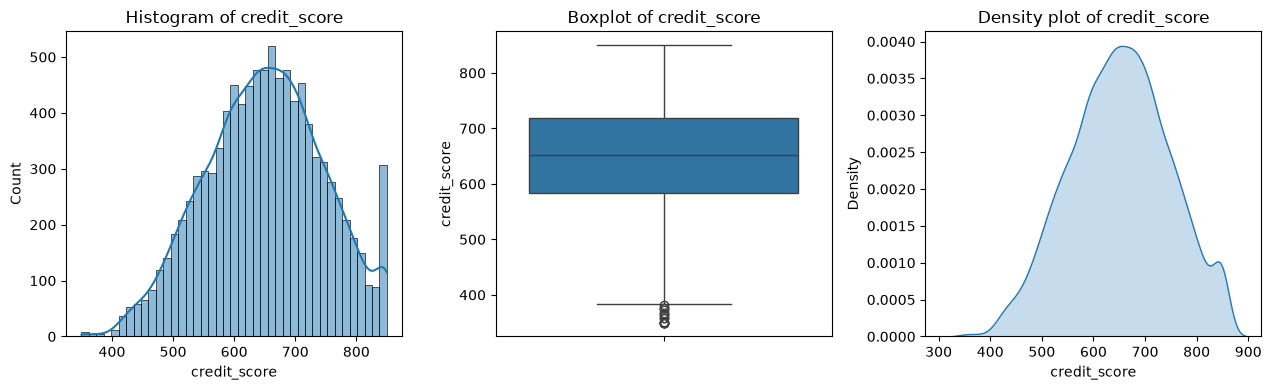

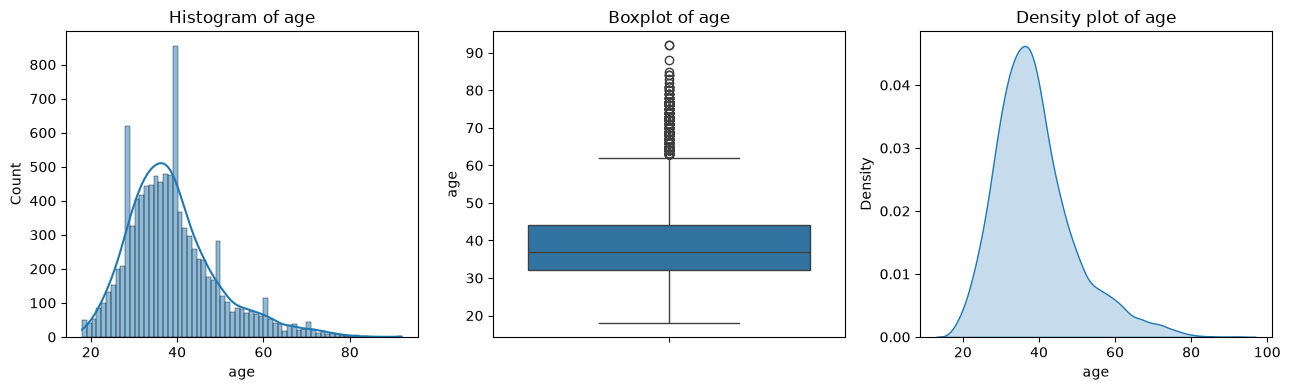

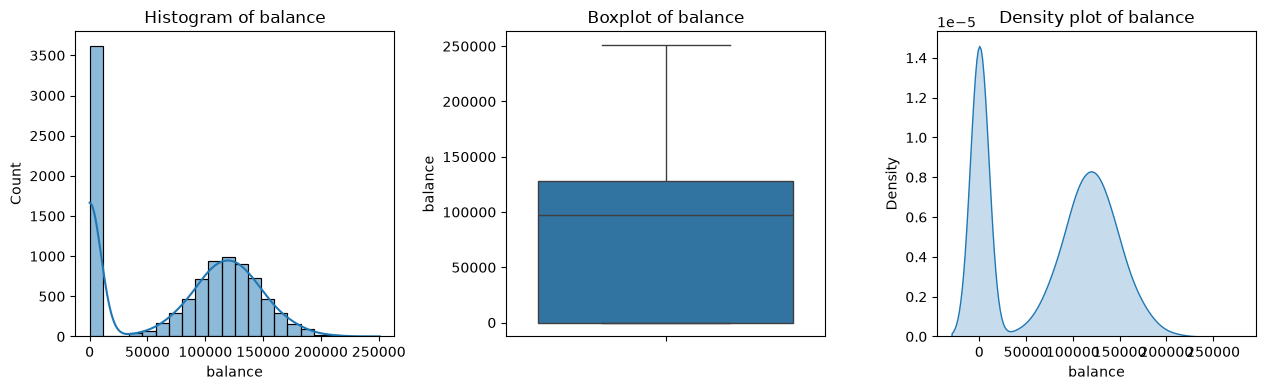

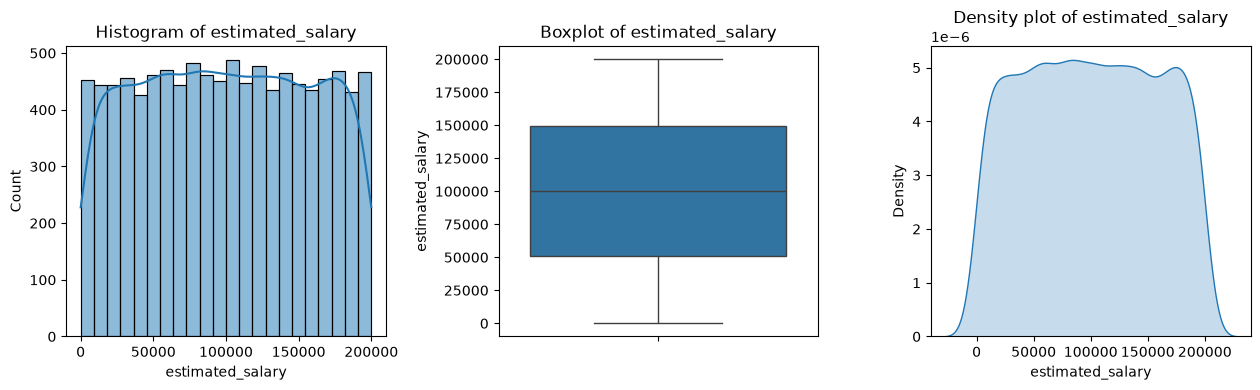

In [39]:
# histogram, boxplot, density plot of numerical columns
num_col=df.drop(columns=["customer_id","gender","country","churn","credit_card","active_member","tenure","products_number"])
for col in num_col:
    plt.figure(figsize=(30,4))

    plt.subplot(1,7,1)
    sns.histplot(df[col],kde=True)
    plt.title(f"Histogram of {col}")

    plt.subplot(1,7,2)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

    plt.subplot(1,7,3)
    sns.kdeplot(df[col],fill=True)
    plt.title(f"Density plot of {col}")

    plt.tight_layout()
    plt.show()


Frequency counts of gender
 gender
Male      5457
Female    4543
Name: count, dtype: int64


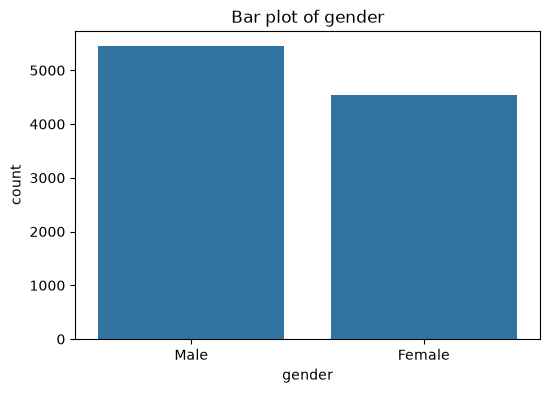


Frequency counts of country
 country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


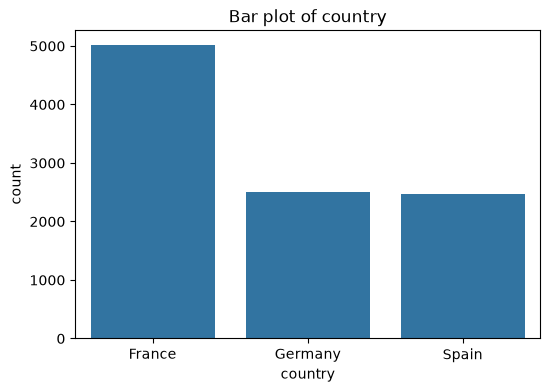


Frequency counts of churn
 churn
0    7963
1    2037
Name: count, dtype: int64


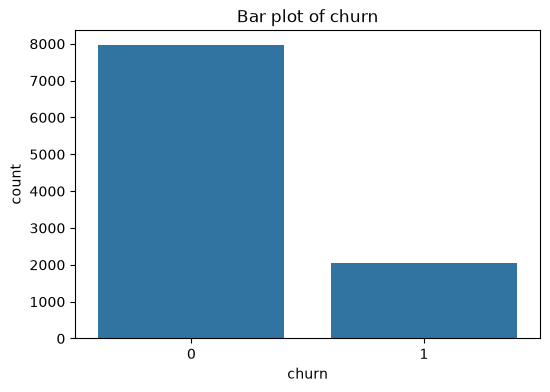


Frequency counts of credit_card
 credit_card
1    7055
0    2945
Name: count, dtype: int64


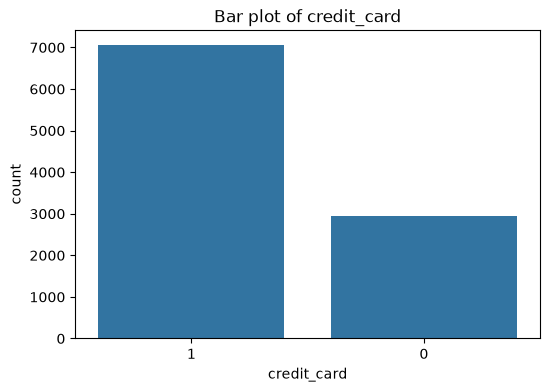


Frequency counts of active_member
 active_member
1    5151
0    4849
Name: count, dtype: int64


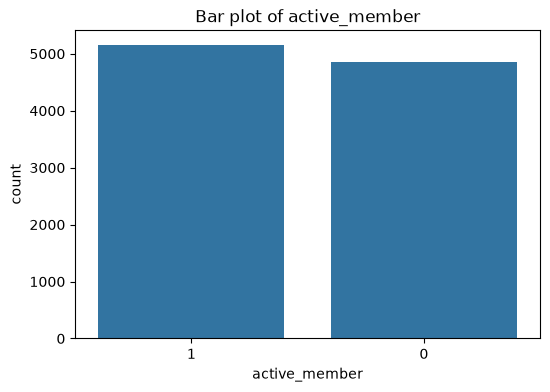


Frequency counts of tenure
 tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64


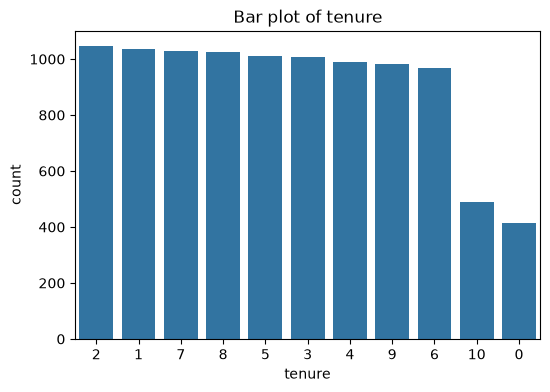


Frequency counts of products_number
 products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


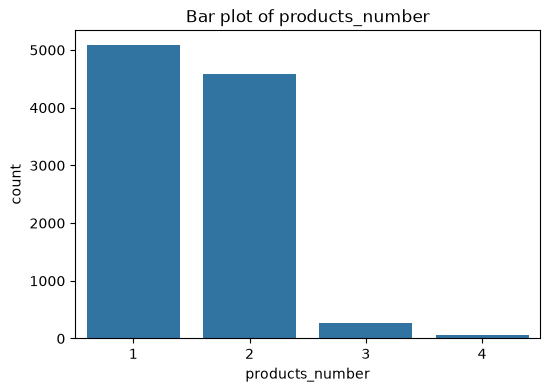

In [40]:
# freaquency count of categorical columns
cat_cols=df[["gender","country","churn","credit_card","active_member","tenure","products_number"]]
for col in cat_cols:
    print(f"\nFrequency counts of {col}\n",df[col].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(x=col,data=df,order=df[col].value_counts().index)
    plt.title(f"Bar plot of {col}")
    plt.show()

### Step - 2 Bivariate analysis

#### Numerical to Categorical

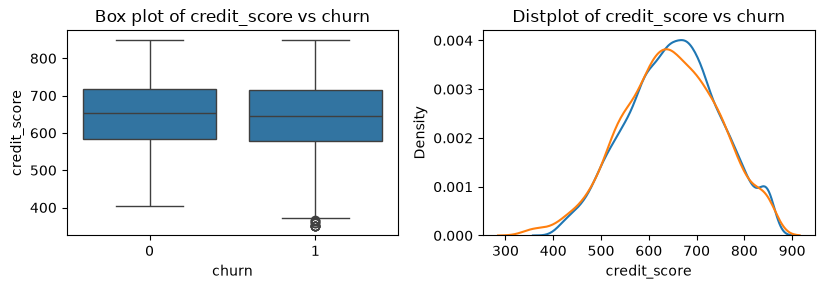

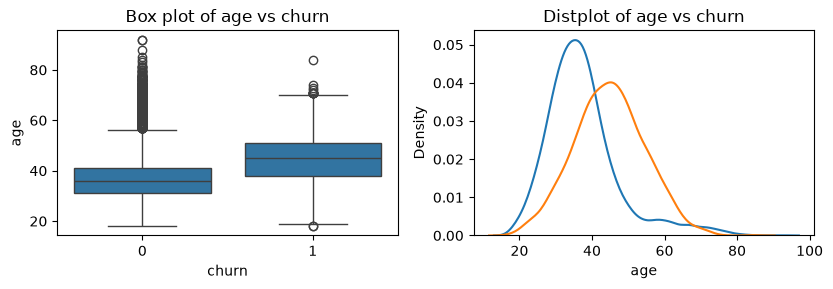

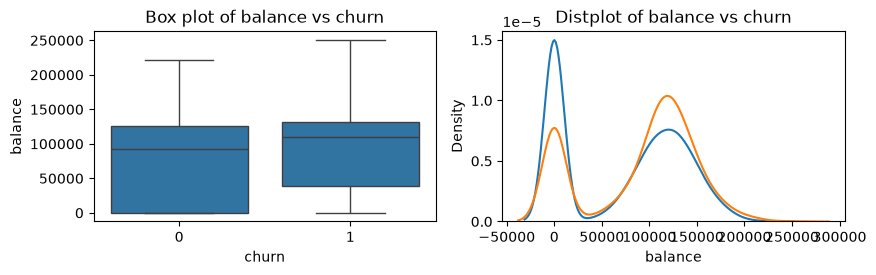

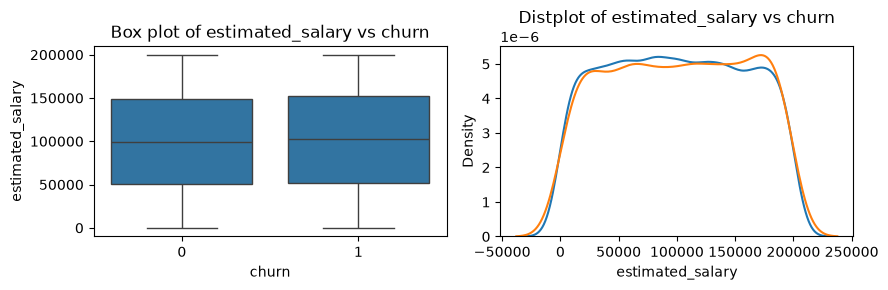

In [41]:
for col in num_col:
    plt.figure(figsize=(25,3))

    plt.subplot(1,6,1)
    sns.boxplot(x="churn",y=col,data=df)
    plt.title(f"Box plot of {col} vs churn")

    plt.subplot(1,6,2)
    sns.distplot(df[df["churn"]==0][col],hist=False)
    sns.distplot(df[df["churn"]==1][col],hist=False)
    plt.title(f"Distplot of {col} vs churn")

    plt.tight_layout()
    plt.show()

#### Categorical columns vs categorical columns

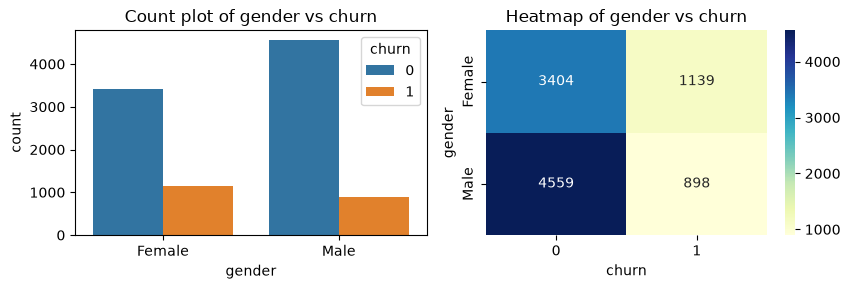

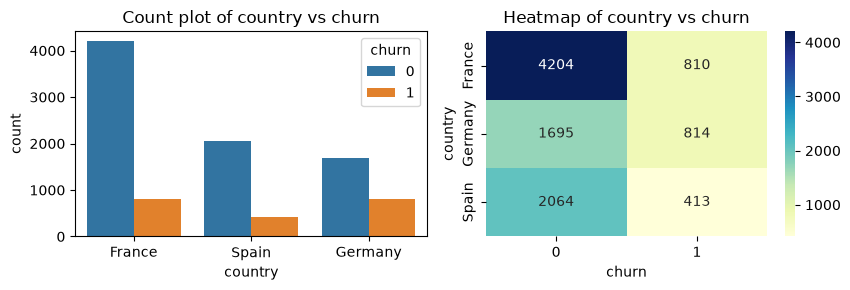

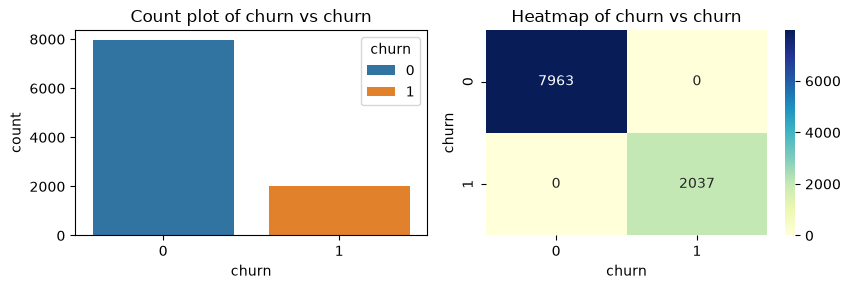

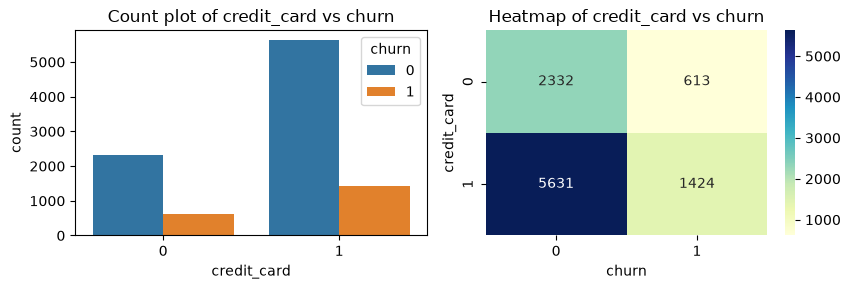

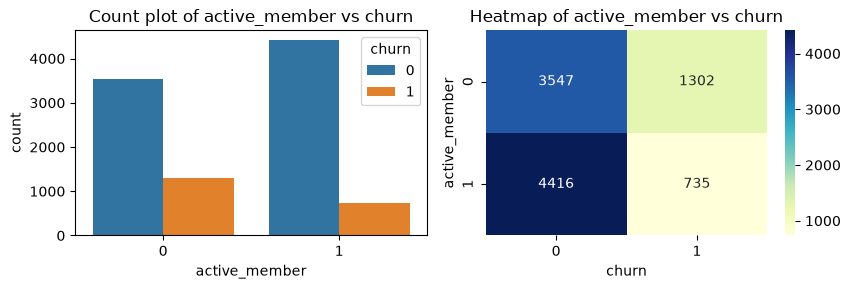

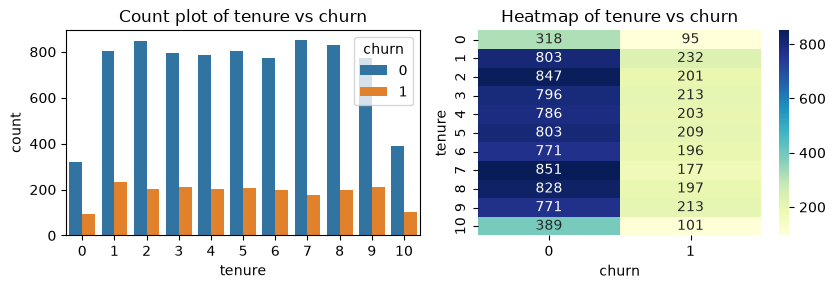

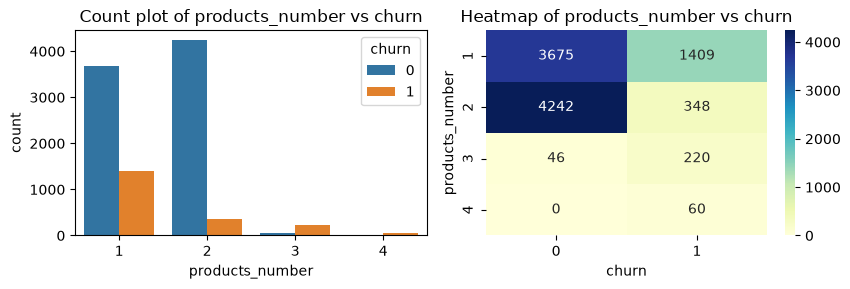

In [42]:
for col in cat_cols:
    plt.figure(figsize=(25,3))

    plt.subplot(1,6,1)
    sns.countplot(x=col,hue="churn",data=df)
    plt.title(f"Count plot of {col} vs churn")

    plt.subplot(1,6,2)
    sns.heatmap(pd.crosstab(df[col],df["churn"]),annot=True,fmt="d",cmap="YlGnBu")
    plt.title(f"Heatmap of {col} vs churn")

    plt.tight_layout()
    plt.show()

### Step - 3 Multivariate analysis

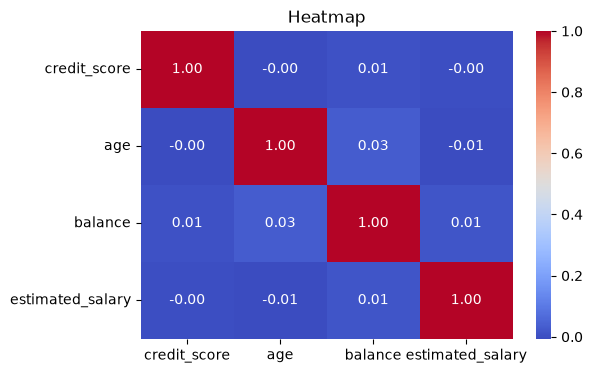

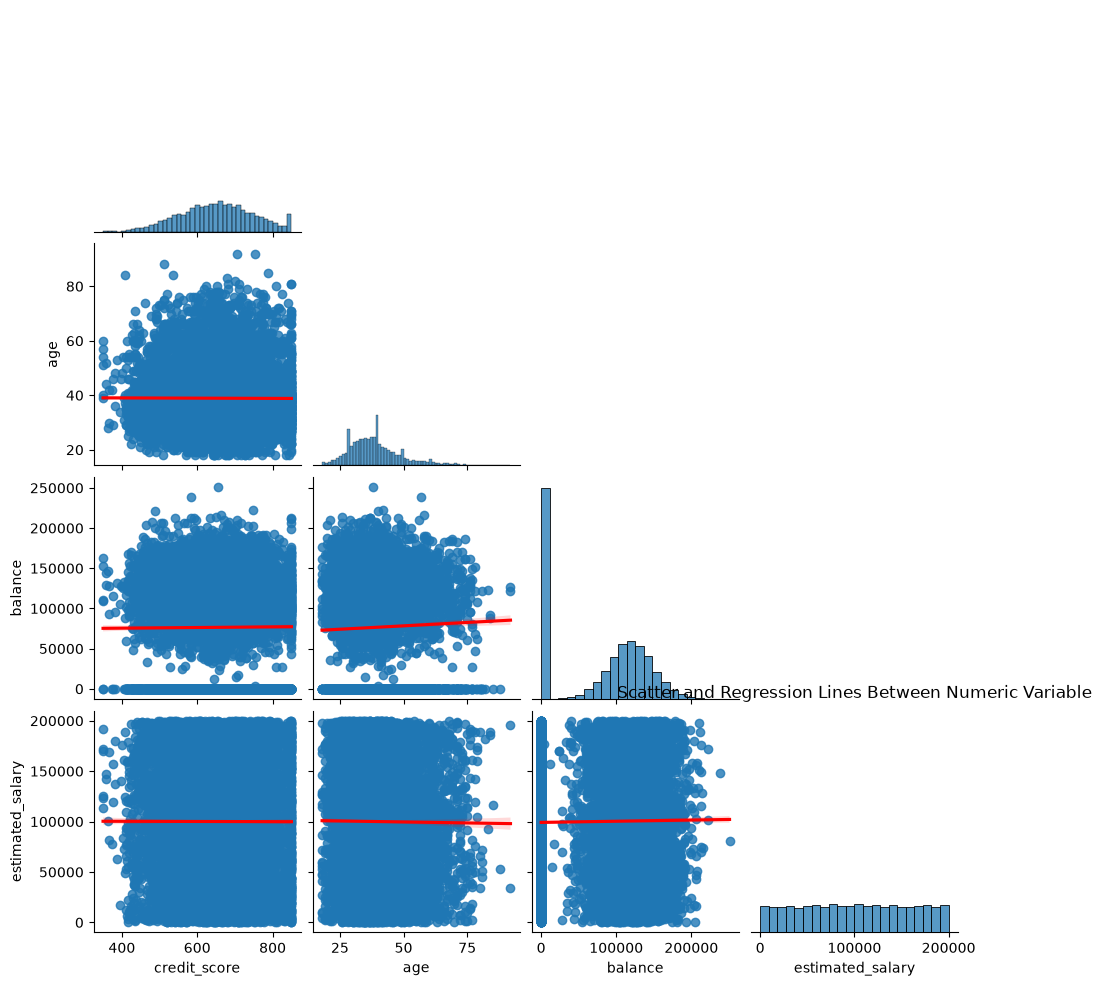

In [43]:
# Coreelation of Numerical Features
corre=num_col.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corre,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Heatmap")
plt.show()

# Pair wise scatter plot + regression line
sns.pairplot(num_col,kind="reg",corner=True,plot_kws={"line_kws":{"color":"red"}})
plt.title(f"Scatter and Regression Lines Between Numeric Variable",y=1.02)
plt.show()


In [44]:
df.head()


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
